In [26]:
library(stringr)
library(dplyr)
library(ggplot2)
library(BiocManager)
library(phyloseq)
library(ggpubr)
library(lme4)
install.packages("tidyr")
library(tidyr)
library(tibble)
library(purrr)
install.packages("broom.mixed")
library(broom.mixed)
install.packages("emmeans")
library(emmeans)
library(glmmTMB)
library(phyloseq)
library(SpiecEasi)
library(igraph)
library(RColorBrewer)
library(scales)
library(vegan)
library(brglm2)

Installing package into ‘/home/ldas/R/x86_64-conda-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)

Warning message in install.packages("tidyr"):
“installation of package ‘tidyr’ had non-zero exit status”
Installing package into ‘/home/ldas/R/x86_64-conda-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)

Installing package into ‘/home/ldas/R/x86_64-conda-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)



In [19]:
keystone <- read.csv("/home/ldas/keystone1.csv")

In [20]:
keystone

Taxon,ASVs,n_ASVs,IS_Status_summary,IS_Human,IS_Cattle,IS_Rodent,NCBI.Search.Results
<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>
Acetitomaculum,ASV1425,2,Unknown,0,0,0,6
Acetitomaculum,ASV1730,2,Unknown,0,0,0,6
Acutalibacter,ASV278,1,Unknown,0,0,0,3
Akkermansia,ASV135,3,Context-dependant,1,1,1,1625
Akkermansia,ASV612,3,Context-dependant,1,1,1,1625
Akkermansia,ASV632,3,Context-dependant,1,1,1,1625
Alistipes,ASV1169,7,Context-dependant,1,1,1,444
Alistipes,ASV13,7,Context-dependant,1,1,1,444
Alistipes,ASV213,7,Context-dependant,1,1,1,444


In [34]:
genus <- readRDS("/home/ldas/ps_genus_manual.rds")

In [37]:
OTU_genus <- readRDS("/home/ldas/otu_pa_matrix.rds")

In [39]:
meta <- genus

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 921 taxa and 142 samples ]
sample_data() Sample Data:       [ 142 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 921 taxa by 9 taxonomic ranks ]

In [40]:
meta <- data.frame(sample_data(genus))

# View
head(meta)

,X,Sample_ID,Corrected_Sample_ID,Cow_ID,DIM_Collected,Date_Collected,Date_Recieved,Farm,Sample_Type,Sex,⋯,fastqspeciesscreen.pct.mouse,fastqspeciesscreen.pct.rRNA,input,filtered,denoisedF,denoisedR,merged,nonchim,Sample_Type2,is.neg
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<lgl>,⋯,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<lgl>
1165D1LM,1165D1LM,1165D1LM,1165D1LM,1165,1,10/13/24,12/9/24,Loehmer,Feces,FALSE,⋯,0.00,88.79,609025,513044,502491,508445,437232,412160,Feces,FALSE
1165D3LM,1165D3LM,1165D3LM,1165D3LM,1165,3,10/15/24,12/9/24,Loehmer,Feces,FALSE,⋯,0.00,88.15,676674,580336,568752,575103,491693,454575,Feces,FALSE
1179D1LM,1179D1LM,1179D1LM,1179D1LM,1179,1,10/12/24,12/9/24,Loehmer,Feces,FALSE,⋯,0.01,89.77,564157,491328,482631,487088,434622,408363,Feces,FALSE
1179D3LM,1179D3LM,1179D3LM,1179D3LM,1179,3,10/14/24,12/9/24,Loehmer,Feces,FALSE,⋯,0.00,88.12,658846,562995,553550,558314,487580,447292,Feces,FALSE
1217D1LM,1217D1LM,1217D1LM,1217D1LM,1217,1,10/13/24,12/9/24,Loehmer,Feces,FALSE,⋯,0.00,89.01,581331,491971,487002,488722,450010,421586,Feces,FALSE
1217D3LM,1217D3LM,1217D3LM,1217D3LM,1217,3,10/15/24,12/9/24,Loehmer,Feces,FALSE,⋯,0.00,88.04,520966,445873,438809,442747,388456,357532,Feces,FALSE


In [41]:
# Make sure factors are correctly coded
meta$Haptoglobin_InflamStat <- factor(meta$Haptoglobin_InflamStat)
meta$Fibrinogen_InflamStat <- factor(meta$Fibrinogen_InflamStat)
# Convert factor to numeric first
meta$Parity_num <- as.numeric(as.character(meta$Parity))
# Collapse into two levels
meta$Parity_bin <- ifelse(meta$Parity_num >= 3, "3plus", "1_2")

meta$ExtractionDate <- factor(meta$ExtractionDate)
meta$Sample_ID <- factor(meta$Sample_ID)
meta$Cow_ID <- factor(meta$Cow_ID)
# Make it a factor
meta$Parity_bin <- factor(meta$Parity_bin)

In [42]:
df <- meta
#df
# Make sure all variables are factors / numeric correctly
# Make sure all variables are correctly typed
df$Haptoglobin_InflamStat <- factor(df$Haptoglobin_InflamStat)
df$Fibrinogen_InflamStat <- factor(df$Fibrinogen_InflamStat)
df$Parity_bin <- factor(df$Parity_bin)
df$ExtractionDate <- factor(df$ExtractionDate)
df$Sample_ID <- factor(df$Sample_ID)
df$BCS <- as.numeric(df$BCS)
df$Cow_ID <- factor(df$Cow_ID)
df$DIM_Collected <- factor(df$DIM_Collected)
results_list <- list()

In [44]:
# Make sure factors are correctly coded
meta$Haptoglobin_InflamStat <- factor(meta$Haptoglobin_InflamStat)
meta$Fibrinogen_InflamStat <- factor(meta$Fibrinogen_InflamStat)

# Convert Parity to numeric first
meta$Parity_num <- as.numeric(as.character(meta$Parity))

# Collapse parity into two levels
meta$Parity_bin <- ifelse(meta$Parity_num >= 3, "3plus", "1_2")
meta$Parity_bin <- factor(meta$Parity_bin)

meta$ExtractionDate <- factor(meta$ExtractionDate)
meta$Sample_ID <- factor(meta$Sample_ID)
meta$Cow_ID <- factor(meta$Cow_ID)

df <- meta

# Make sure all variables are correctly typed
df$Haptoglobin_InflamStat <- factor(df$Haptoglobin_InflamStat)
df$Fibrinogen_InflamStat <- factor(df$Fibrinogen_InflamStat)
df$Parity_bin <- factor(df$Parity_bin)
df$ExtractionDate <- factor(df$ExtractionDate)
df$Sample_ID <- factor(df$Sample_ID)
df$BCS <- as.numeric(df$BCS)
df$Cow_ID <- factor(df$Cow_ID)
df$DIM_Collected <- factor(df$DIM_Collected)

results_list <- list()

In [48]:
results_list <- list()

for (taxon in genus_cols) {
  
  df_model <- model_input_genus[, c("Fibrinogen_InflamStat"), drop = FALSE]
  
  df_model$presence <- as.numeric(model_input_genus[[taxon]])
  
  df_model <- df_model %>%
    dplyr::filter(
      !is.na(presence),
      !is.na(Fibrinogen_InflamStat)
    )
  
  if (length(unique(df_model$presence)) < 2) next
  if (sum(df_model$presence == 1, na.rm = TRUE) < 5) next
  
  fit <- tryCatch(
    glm(
      presence ~ Fibrinogen_InflamStat,
      data = df_model,
      family = binomial("logit"),
      method = "brglmFit"
    ),
    error = function(e) NULL
  )
  
  if (is.null(fit)) next
  
  sm <- summary(fit)
  
  coef_name <- grep(
    "Fibrinogen_InflamStat",
    rownames(sm$coefficients),
    value = TRUE
  )
  
  if (length(coef_name) == 0) next
  
  beta <- sm$coefficients[coef_name, "Estimate"]
  se   <- sm$coefficients[coef_name, "Std. Error"]
  pval <- sm$coefficients[coef_name, "Pr(>|z|)"]
  
  results_list[[taxon]] <- data.frame(
    Genus = taxon,
    OR = exp(beta),
    Lower_CI = exp(beta - 1.96 * se),
    Upper_CI = exp(beta + 1.96 * se),
    p.value = pval
  )
}

or_table_Fibrinogen_genus_brglm2_nocov <- do.call(rbind, results_list)

or_table_Fibrinogen_genus_brglm2_nocov$FDR <- p.adjust(
  or_table_Fibrinogen_genus_brglm2_nocov$p.value,
  method = "BH"
)

or_table_Fibrinogen_genus_brglm2_nocov <- or_table_Fibrinogen_genus_brglm2_nocov %>%
  arrange(p.value)

head(or_table_Fibrinogen_genus_brglm2_nocov)

,Genus,OR,Lower_CI,Upper_CI,p.value,FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dorea,Dorea,3.1301018,1.53812305,6.3698008,0.001645294,0.1957900
Oscillibacter,Oscillibacter,0.4285717,0.20922567,0.8778737,0.020556207,0.6996399
Salmonella,Salmonella,0.2020860,0.04458245,0.9160278,0.038103010,0.6996399
Butyribacter,Butyribacter,3.3673454,1.00061170,11.3320830,0.049880460,0.6996399
[Eubacterium] siraeum group,[Eubacterium] siraeum group,2.3618317,0.95508000,5.8406093,0.062814018,0.6996399
Prevotellaceae UCG-004,Prevotellaceae UCG-004,0.5131682,0.25375252,1.0377889,0.063344294,0.6996399


In [49]:
# Make sure reference is correct
model_input_genus$Haptoglobin_InflamStat <- factor(model_input_genus$Haptoglobin_InflamStat)

model_input_genus$Haptoglobin_InflamStat <- relevel(
  model_input_genus$Haptoglobin_InflamStat,
  ref = "Normal"
)

results_list <- list()

for (taxon in genus_cols) {
  
  df_model <- model_input_genus[, c("Haptoglobin_InflamStat"), drop = FALSE]
  
  df_model$presence <- as.numeric(model_input_genus[[taxon]])
  
  df_model <- df_model %>%
    dplyr::filter(
      !is.na(presence),
      !is.na(Haptoglobin_InflamStat)
    )
  
  if (length(unique(df_model$presence)) < 2) next
  if (sum(df_model$presence == 1, na.rm = TRUE) < 5) next
  
  fit <- tryCatch(
    glm(
      presence ~ Haptoglobin_InflamStat,
      data = df_model,
      family = binomial("logit"),
      method = "brglmFit"
    ),
    error = function(e) NULL
  )
  
  if (is.null(fit)) next
  
  sm <- summary(fit)
  
  coef_name <- grep(
    "Haptoglobin_InflamStat",
    rownames(sm$coefficients),
    value = TRUE
  )
  
  if (length(coef_name) == 0) next
  
  beta <- sm$coefficients[coef_name, "Estimate"]
  se   <- sm$coefficients[coef_name, "Std. Error"]
  pval <- sm$coefficients[coef_name, "Pr(>|z|)"]
  
  results_list[[taxon]] <- data.frame(
    Genus = taxon,
    OR = exp(beta),
    Lower_CI = exp(beta - 1.96 * se),
    Upper_CI = exp(beta + 1.96 * se),
    p.value = pval
  )
}

# Combine results
or_table_Haptoglobin_genus_brglm2_nocov <- do.call(rbind, results_list)

or_table_Haptoglobin_genus_brglm2_nocov$FDR <- p.adjust(
  or_table_Haptoglobin_genus_brglm2_nocov$p.value,
  method = "BH"
)

or_table_Haptoglobin_genus_brglm2_nocov <- or_table_Haptoglobin_genus_brglm2_nocov %>%
  arrange(p.value)

# Save
write.csv(
  or_table_Haptoglobin_genus_brglm2_nocov,
  "or_table_Haptoglobin_genus_brglm2_nocov.csv",
  row.names = FALSE
)

saveRDS(
  or_table_Haptoglobin_genus_brglm2_nocov,
  "or_table_Haptoglobin_genus_brglm2_nocov.rds"
)

head(or_table_Haptoglobin_genus_brglm2_nocov)

,Genus,OR,Lower_CI,Upper_CI,p.value,FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Zag_111,Zag_111,4.9680032,1.8701692,13.1972312,0.001300287,0.1497143
UCG-002,UCG-002,3.9200239,1.6159093,9.5095604,0.002516207,0.1497143
Sphaerochaeta,Sphaerochaeta,4.9111106,1.3640769,17.6815602,0.014890147,0.5610364
Anaerovorax,Anaerovorax,3.3095915,1.2188495,8.9866679,0.018858368,0.5610364
Dielma,Dielma,2.7951238,1.1198343,6.9766723,0.027628429,0.6252990
Marvinbryantia,Marvinbryantia,0.3731282,0.1519201,0.9164336,0.031527679,0.6252990


In [50]:
# Save
write.csv(
  or_table_Fibrinogen_genus_brglm2_nocov,
  "or_table_Fibrinogen_genus_brglm2_nocov.csv",
  row.names = FALSE
)

saveRDS(
  or_table_Fibrinogen_genus_brglm2_nocov,
  "or_table_Fibrinogen_genus_brglm2_nocov.rds"
)

In [66]:
or_table_Fibrinogen_genus_brglm2_nocov$Genus <- trimws(or_table_Fibrinogen_genus_brglm2_nocov$Genus)

or_table_Fibrinogen_genus_brglm2_nocov$Keystone <- ifelse(
  or_table_Fibrinogen_genus_brglm2_nocov$Genus %in% keystone$Taxon,
  "Yes",
  "No"
)

In [67]:
or_table_Haptoglobin_genus_brglm2_nocov$Genus <- trimws(or_table_Haptoglobin_genus_brglm2_nocov$Genus)

or_table_Haptoglobin_genus_brglm2_nocov$Keystone <- ifelse(
  or_table_Haptoglobin_genus_brglm2_nocov$Genus %in% keystone$Taxon,
  "Yes",
  "No"
)

In [57]:
or_table_Fibrinogen_genus_brglm2$Genus <- trimws(or_table_Fibrinogen_genus_brglm2$Genus)

or_table_Fibrinogen_genus_brglm2$Keystone <- ifelse(
  or_table_Fibrinogen_genus_brglm2$Genus %in% keystone$Taxon,
  "Yes",
  "No"
)

In [68]:
table(or_table_Fibrinogen_genus_brglm2_nocov$Keystone)
table(or_table_Haptoglobin_genus_brglm2_nocov$Keystone)


 No Yes 
 82  37 


 No Yes 
 82  37 

In [60]:
table(or_table_Fibrinogen_genus_brglm2$Keystone)
table(or_table_Haptoglobin_genus_brglm2$Keystone)


 No Yes 
 82  37 


 No Yes 
 82  37 

In [59]:
or_table_Haptoglobin_genus_brglm2$Genus <- trimws(or_table_Haptoglobin_genus_brglm2$Genus)

or_table_Haptoglobin_genus_brglm2$Keystone <- ifelse(
  or_table_Haptoglobin_genus_brglm2$Genus %in% keystone$Taxon,
  "Yes",
  "No"
)

In [69]:
write.csv(or_table_Fibrinogen_genus_brglm2_nocov,
          "or_table_Fibrinogen_genus_brglm2_nocov_with_keystone.csv",
          row.names = FALSE)

write.csv(or_table_Haptoglobin_genus_brglm2_nocov,
          "or_table_Haptoglobin_genus_brglm2_nocov_with_keystone.csv",
          row.names = FALSE)

In [6]:
or_table_Fibrinogen_genus_brglm2 <- read.csv(
  "/home/ldas/or_table_Fibrinogen_genus_brglm2_with_keystone.csv"
)
or_table_Haptoglobin_genus_brglm2 <- read.csv(
  "/home/ldas/or_table_Haptoglobin_genus_brglm2_with_keystone.csv"
)

In [10]:
or_table_Fibrinogen_genus_brglm2

Genus,OR,Lower_CI,Upper_CI,p.value,FDR,Keystone
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Dorea,3.4399073,1.61671906,7.3191209,0.001341025,0.1595819,No
Salmonella,0.1649227,0.03734534,0.7283235,0.017391031,0.6956536,No
Oscillibacter,0.4205442,0.20280304,0.8720652,0.019918007,0.6956536,No
Zag_111,3.2392997,1.04342553,10.0563601,0.041997271,0.6956536,No
Frisingicoccus,0.1661566,0.02895465,0.9534921,0.044069988,0.6956536,No
Ruminococcus,4.2469019,0.98945161,18.2284568,0.051686867,0.6956536,Yes
Butyribacter,3.2992118,0.98061629,11.0999567,0.053808074,0.6956536,No
Erysipelotrichaceae UCG-009,0.1841775,0.03261929,1.0399167,0.055405683,0.6956536,No
Gordonibacter,0.2196255,0.04552093,1.0596306,0.059044190,0.6956536,No


In [12]:
library(dplyr)
library(forestploter)
library(grid)
library(stringr)

In [14]:
fibrino <- or_table_Fibrinogen_genus_brglm2 %>%
  filter(Keystone == "Yes") %>%
  mutate(Genus = str_trim(Genus)) %>%
  select(Genus, OR, Lower_CI, Upper_CI) %>%
  rename(
    OR_Fibrinogen = OR,
    Lower_CI_Fibrinogen = Lower_CI,
    Upper_CI_Fibrinogen = Upper_CI
  )

hapto <- or_table_Haptoglobin_genus_brglm2 %>%
  filter(Keystone == "Yes") %>%
  mutate(Genus = str_trim(Genus)) %>%
  select(Genus, OR, Lower_CI, Upper_CI) %>%
  rename(
    OR_Haptoglobin = OR,
    Lower_CI_Haptoglobin = Lower_CI,
    Upper_CI_Haptoglobin = Upper_CI
  )


In [15]:
keystone_or <- full_join(
  fibrino,
  hapto,
  by = "Genus"
)


In [77]:
svglite("better_signal_genus_forestplot_nocov.svg", width = 10, height = 8)
print(p_signal)
dev.off()

pdf 
  2

In [22]:

# Prepare plot table

plot_df <- keystone_or %>%
  mutate(
    Fibrinogen_CI = ifelse(
      is.na(OR_Fibrinogen),
      "",
      sprintf("%.2f (%.2f–%.2f)",
              OR_Fibrinogen,
              Lower_CI_Fibrinogen,
              Upper_CI_Fibrinogen)
    ),
    
    Haptoglobin_CI = ifelse(
      is.na(OR_Haptoglobin),
      "",
      sprintf("%.2f (%.2f–%.2f)",
              OR_Haptoglobin,
              Lower_CI_Haptoglobin,
              Upper_CI_Haptoglobin)
    ),
    
    ` ` = "      ",
    `  ` = "      "
  ) %>%
  arrange(tolower(Genus))



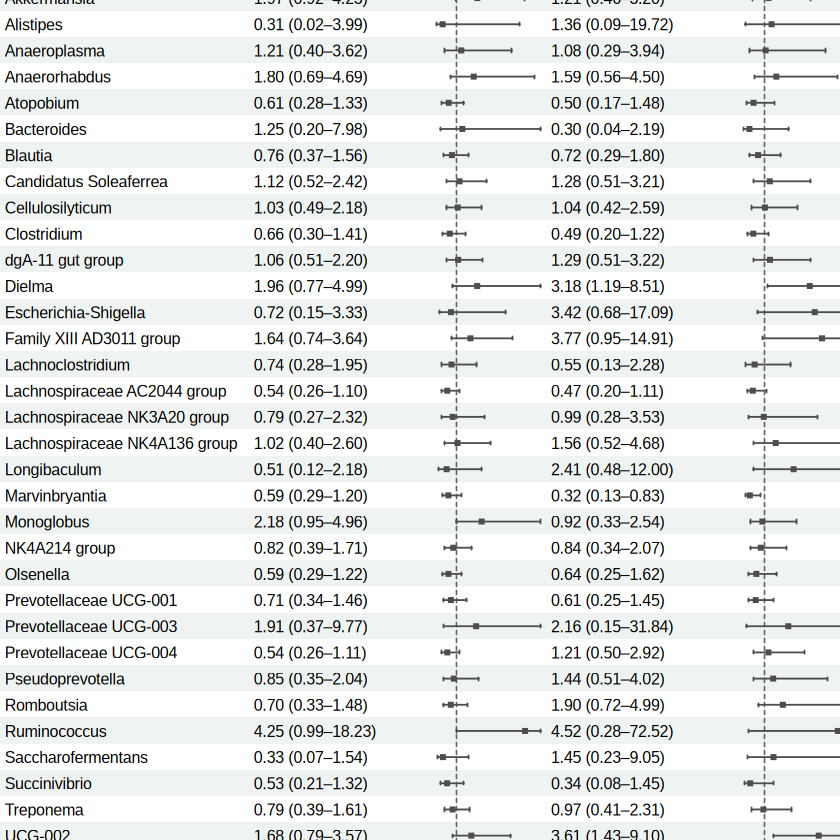

In [23]:
# Wider plotting columns
plot_df <- plot_df %>%
  mutate(
    ` `  = "                    ",
    `  ` = "                    "
  )

table_df <- plot_df %>%
  select(
    Genus,
    `Fibrinogen OR (95% CI)` = Fibrinogen_CI,
    ` `,
    `Haptoglobin OR (95% CI)` = Haptoglobin_CI,
    `  `
  )

# Cap CI only for plotting
x_min <- 0
x_max <- 5

plot_df <- plot_df %>%
  mutate(
    Lower_CI_Fibrinogen_plot = ifelse(is.na(Lower_CI_Fibrinogen), NA, pmax(Lower_CI_Fibrinogen, x_min)),
    Upper_CI_Fibrinogen_plot = ifelse(is.na(Upper_CI_Fibrinogen), NA, pmin(Upper_CI_Fibrinogen, x_max)),
    Lower_CI_Haptoglobin_plot = ifelse(is.na(Lower_CI_Haptoglobin), NA, pmax(Lower_CI_Haptoglobin, x_min)),
    Upper_CI_Haptoglobin_plot = ifelse(is.na(Upper_CI_Haptoglobin), NA, pmin(Upper_CI_Haptoglobin, x_max))
  )

tm <- forest_theme(
  base_size = 9,
  refline_gp = gpar(col = "gray40", lty = 2, lwd = 1),
  ci_pch = 15,
  ci_col = "gray30",
  ci_fill = "gray30",
  ci_lwd = 1.1,
  ci_Theight = 0.12,
  xaxis_gp = gpar(cex = 0.7)
)

p <- forest(
  table_df,
  est = list(
    plot_df$OR_Fibrinogen,
    plot_df$OR_Haptoglobin
  ),
  lower = list(
    plot_df$Lower_CI_Fibrinogen_plot,
    plot_df$Lower_CI_Haptoglobin_plot
  ),
  upper = list(
    plot_df$Upper_CI_Fibrinogen_plot,
    plot_df$Upper_CI_Haptoglobin_plot
  ),
  ci_column = c(3, 5),
  ref_line = 1,
  xlim = c(x_min, x_max),
  ticks_at = c(0, 1, 2, 3, 4, 5),
  theme = tm
)

p

In [91]:
library(svglite)

svglite("keystone_forestplot_clean_axis.svg", width = 14, height = 9)
print(p)
dev.off()

pdf 
  2

In [26]:
library(dplyr)
library(forestploter)
library(grid)
library(stringr)
library(svglite)

# Combine all genus-level nocov OR results


fibrino_all <- or_table_Fibrinogen_genus_brglm2 %>%
  mutate(Genus = str_trim(Genus)) %>%
  select(Genus, OR, Lower_CI, Upper_CI, p.value, FDR) %>%
  rename(
    OR_Fibrinogen = OR,
    Lower_CI_Fibrinogen = Lower_CI,
    Upper_CI_Fibrinogen = Upper_CI,
    p_Fibrinogen = p.value,
    FDR_Fibrinogen = FDR
  )

hapto_all <- or_table_Haptoglobin_genus_brglm2 %>%
  mutate(Genus = str_trim(Genus)) %>%
  select(Genus, OR, Lower_CI, Upper_CI, p.value, FDR) %>%
  rename(
    OR_Haptoglobin = OR,
    Lower_CI_Haptoglobin = Lower_CI,
    Upper_CI_Haptoglobin = Upper_CI,
    p_Haptoglobin = p.value,
    FDR_Haptoglobin = FDR
  )

all_or <- full_join(fibrino_all, hapto_all, by = "Genus")

In [25]:
# Select better-signal genera (CI not crossing 1 in either marker)


plot_df_signal <- all_or %>%
  mutate(
    Sig_Fibrinogen = !is.na(Lower_CI_Fibrinogen) &
      (Lower_CI_Fibrinogen > 1 | Upper_CI_Fibrinogen < 1),
    
    Sig_Haptoglobin = !is.na(Lower_CI_Haptoglobin) &
      (Lower_CI_Haptoglobin > 1 | Upper_CI_Haptoglobin < 1),
    
    Signal = Sig_Fibrinogen | Sig_Haptoglobin
  ) %>%
  filter(Signal == TRUE) %>%
  mutate(
    Fibrinogen_CI = ifelse(
      is.na(OR_Fibrinogen),
      "",
      sprintf("%.2f (%.2f–%.2f)",
              OR_Fibrinogen,
              Lower_CI_Fibrinogen,
              Upper_CI_Fibrinogen)
    ),
    
    Haptoglobin_CI = ifelse(
      is.na(OR_Haptoglobin),
      "",
      sprintf("%.2f (%.2f–%.2f)",
              OR_Haptoglobin,
              Lower_CI_Haptoglobin,
              Upper_CI_Haptoglobin)
    ),
    
    ` ` = "      ",
    `  ` = "      "
  ) %>%
  arrange(tolower(Genus))

refline_lty, refline_col will be deprecated, use refline_gp instead.



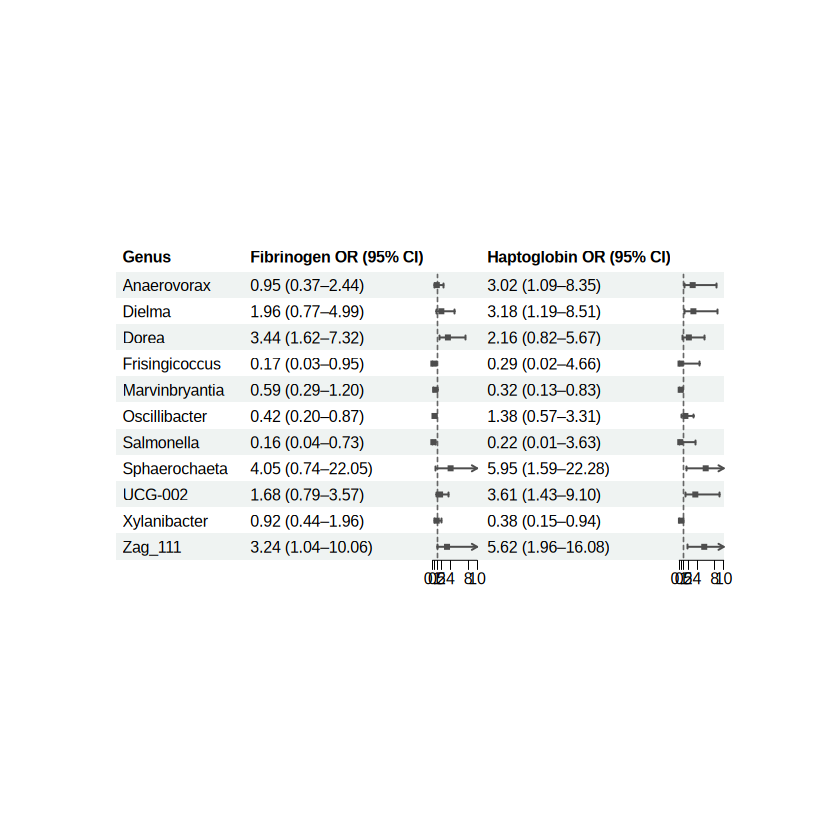

In [24]:
# Table for forestploter

table_df_signal <- plot_df_signal %>%
  select(
    Genus,
    `Fibrinogen OR (95% CI)` = Fibrinogen_CI,
    ` `,
    `Haptoglobin OR (95% CI)` = Haptoglobin_CI,
    `  `
  )

# Forest theme

tm <- forest_theme(
  base_size = 9,
  refline_col = "gray40",
  refline_lty = "dashed",
  ci_pch = 15,
  ci_col = "gray30",
  ci_fill = "gray30",
  ci_alpha = 1,
  ci_lwd = 1.2,
  ci_Theight = 0.15
)


# Forest plot


p_signal <- forest(
  table_df_signal,
  
  est = list(
    plot_df_signal$OR_Fibrinogen,
    plot_df_signal$OR_Haptoglobin
  ),
  
  lower = list(
    plot_df_signal$Lower_CI_Fibrinogen,
    plot_df_signal$Lower_CI_Haptoglobin
  ),
  
  upper = list(
    plot_df_signal$Upper_CI_Fibrinogen,
    plot_df_signal$Upper_CI_Haptoglobin
  ),
  
  ci_column = c(3, 5),
  ref_line = 1,
  xlim = c(0, 10),
  ticks_at = c(0, 0.5, 1, 2, 4, 8, 10),
  theme = tm
)

p_signal